In [2]:
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler
import plotly.express as px
from astropy.table import conf


# Reading FITS files

In [3]:
DR16 = fits.open("DR16Q_v4.fits")   #original
Shen = fits.open("DR16Q_Shen.fits") #Shen w/ BH masses

In [4]:
data = DR16[1].data
data_mask = (1.2 < data.Z) & (data.Z < 2)
data = data[data_mask]
data2 = Shen[1].data[data_mask]
data2[:10]
print(data.shape)


(285603,)


In [5]:

t = Table.read("DR16Q_v4.fits", hdu = 1)
t2 = Table.read("DR16Q_Shen.fits", hdu = 1)
t["LOGMBH"] = t2["LOGMBH"]

print(t["SDSS_NAME",'LOGMBH'][:10])
print(t2['SDSS_NAME', 'LOGMBH'][:10])

    SDSS_NAME            LOGMBH     
------------------ -----------------
000000.15+353104.2 9.073521493837719
000000.33+310325.3 8.985320040245467
000000.36+070350.8 8.065870075869602
000000.36+274356.2 8.673876393640597
000000.45+092308.2  9.54355224492726
000000.45+174625.4 8.642687394735031
000000.47-002703.9 7.434441387709123
000000.57+055630.8 8.665776832933926
000000.62+311944.3 9.397434363897636
000000.66+145828.8  8.96232060613088
    SDSS_NAME            LOGMBH     
------------------ -----------------
000000.15+353104.2 9.073521493837719
000000.33+310325.3 8.985320040245467
000000.36+070350.8 8.065870075869602
000000.36+274356.2 8.673876393640597
000000.45+092308.2  9.54355224492726
000000.45+174625.4 8.642687394735031
000000.47-002703.9 7.434441387709123
000000.57+055630.8 8.665776832933926
000000.62+311944.3 9.397434363897636
000000.66+145828.8  8.96232060613088


## Brightness and Redshift

Text(0.5, 1.0, 'Redshift')

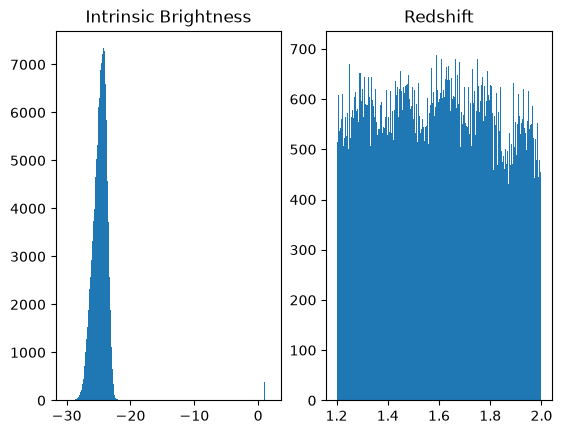

In [6]:
MIgood = data.M_I != -999
Zgood = data.Z != -999

fig,axes = plt.subplots(1,2)
axes[0].hist(data.M_I[MIgood], bins = 500)
axes[0].set_title('Intrinsic Brightness')

axes[1].hist(data.Z[Zgood], bins = 500)
axes[1].set_title('Redshift')

## Bands Magnitude Histogram

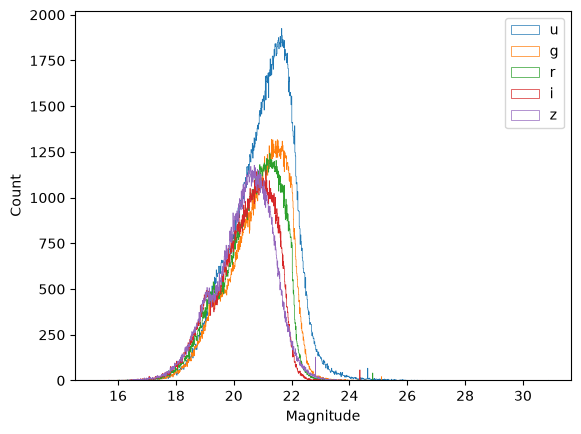

In [7]:
u_mag = data.PSFMAG[:, 0]
g_mag = data.PSFMAG[:, 1]
r_mag = data.PSFMAG[:, 2]
i_mag = data.PSFMAG[:, 3]
z_mag = data.PSFMAG[:, 4]

ug = data.PSFMAG[:, 0] != -9999
gg = data.PSFMAG[:, 1] != -9999
rg = data.PSFMAG[:, 2] != -9999
ig = data.PSFMAG[:, 3] != -9999
zg = data.PSFMAG[:, 4] != -9999

u_mag = u_mag[ug]
g_mag = g_mag[gg]
r_mag = r_mag[rg]
i_mag = i_mag[ig]
z_mag = z_mag[zg]

plt.hist(u_mag ,bins = 1000, linewidth = 0.5, histtype='step')
plt.hist(g_mag ,bins = 1000, linewidth = 0.5, histtype='step')
plt.hist(r_mag ,bins = 1000, linewidth = 0.5, histtype='step')
plt.hist(i_mag ,bins = 1000, linewidth = 0.5, histtype='step')
plt.hist(z_mag ,bins = 1000, linewidth = 0.5, histtype='step')
plt.legend(['u','g','r','i','z'])
# plt.axis([15, 27.5, 0, 5000])
plt.ylabel('Count')
plt.xlabel('Magnitude')
plt.show()

## Redshift vs Bands

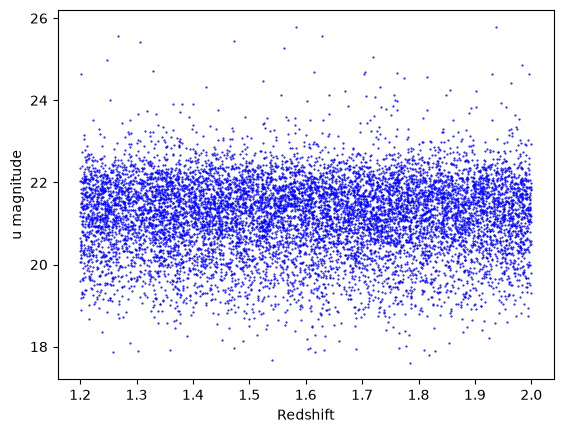

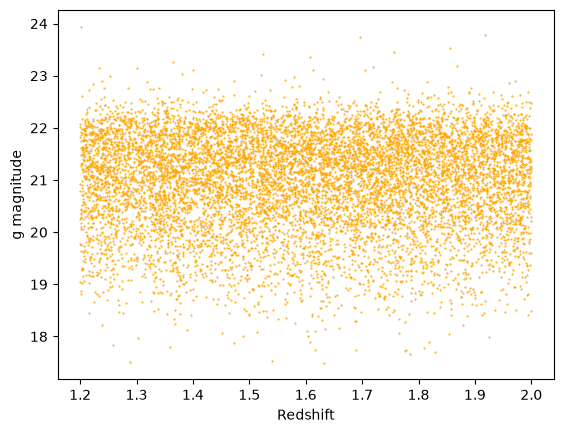

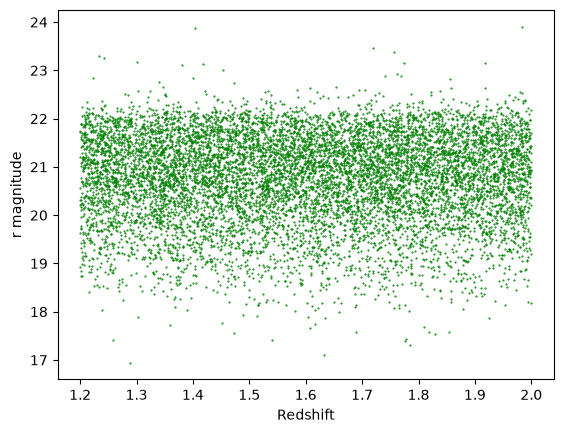

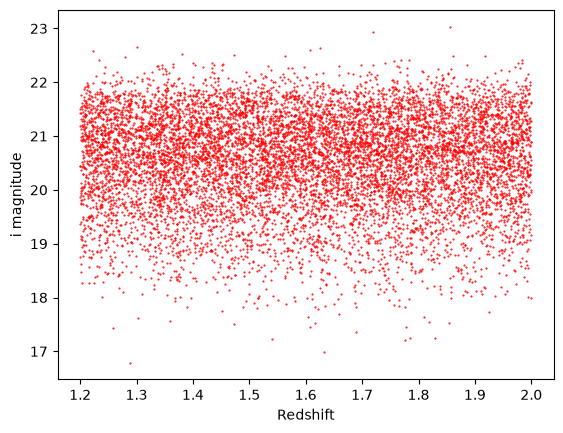

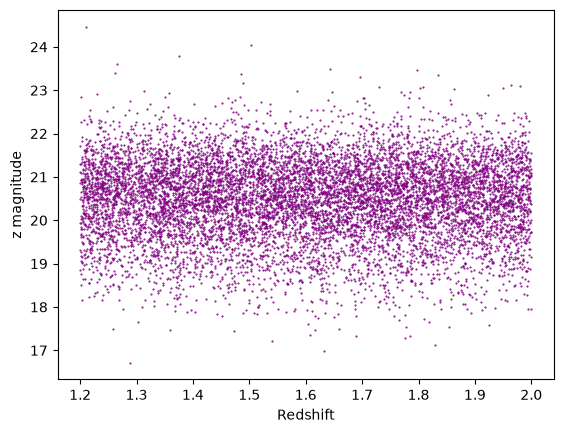

In [8]:
plt.figure()
for i in range(10000):
    plt.plot(data.Z[i], u_mag[i], markersize=1, marker=".", color="blue")
plt.xlabel("Redshift")
plt.ylabel("u magnitude")
plt.show()

plt.figure()
for i in range(10000):
    plt.plot(data.Z[i], g_mag[i], markersize=1, marker=".", color="orange")
plt.xlabel("Redshift")
plt.ylabel("g magnitude")
plt.show()

plt.figure()
for i in range(10000):
    plt.plot(data.Z[i], r_mag[i], markersize=1, marker=".", color="green")
plt.xlabel("Redshift")
plt.ylabel("r magnitude")
plt.show()

plt.figure()
for i in range(10000):
    plt.plot(data.Z[i], i_mag[i], markersize=1, marker=".", color="red")
plt.xlabel("Redshift")
plt.ylabel("i magnitude")
plt.show()

plt.figure()
for i in range(10000):
    plt.plot(data.Z[i], z_mag[i], markersize=1, marker=".", color="purple")
plt.xlabel("Redshift")
plt.ylabel("z magnitude")
plt.show()

## Black Hole Mass Histogram

[8.06587008 8.67387639 9.39743436 ... 8.49576277 8.59796181 9.22546029]


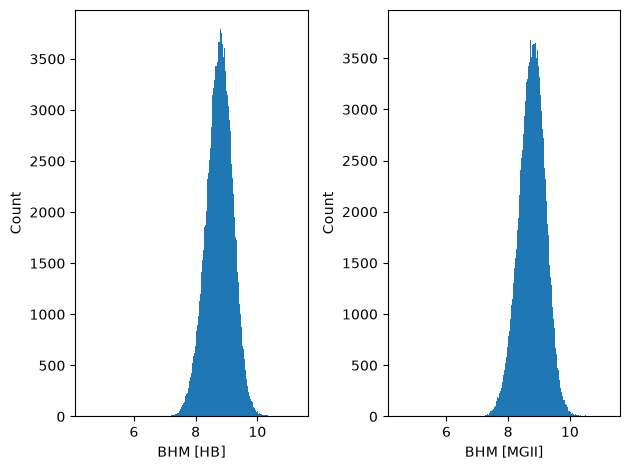

In [9]:
BH_good = data2.LOGMBH != 0
BHM = data2.LOGMBH[BH_good]
BH_MGIIgood = data2.LOGMBH_MGII != 0
print(data2.LOGMBH)
fig, axis = plt.subplots(1,2)

axis[0].hist(BHM, bins = 500)
axis[0].set_xlabel('BHM [HB]')
axis[0].set_ylabel('Count')

axis[1].hist(data2.LOGMBH_MGII[BH_MGIIgood], bins = 500)
axis[1].set_xlabel('BHM [MGII]')
axis[1].set_ylabel('Count')
plt.tight_layout()



In [11]:
print(max(t["LOGMBH"]), min(t['LOGMBH']))
print(max(t["PSFMAG"]), min(t['PSFMAG']))


11.471104808291777 0.0


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## U-band vs BH Mass

In [19]:
valid_bands = []

for i in range(len(t)):
    if (
        (t["LOGMBH"][i] > 0) and
        (t["PSFMAG"][i, 0] != -9999) and
        (t["PSFMAG"][i, 1] != -9999) and
        (t["PSFMAG"][i, 2] != -9999) and
        (t["PSFMAG"][i, 3] != -9999) and
        (t["PSFMAG"][i, 4] != -9999)):
        valid_bands.append([
            t["LOGMBH"][i],
            t["PSFMAG"][i, 0],
            t["PSFMAG"][i, 1],
            t["PSFMAG"][i, 2],
            t["PSFMAG"][i, 3],
            t["PSFMAG"][i, 4],
            t["SDSS_NAME"][i]])

valid_bands_df = pd.DataFrame(
    valid_bands,
    columns=["LOGMBH", "u_mag", "g_mag", "r_mag", "i_mag", "z_mag", "SDSS_NAME"]
)

In [17]:

print(valid_bands[1])
print(len(valid_bands))

['8.985320040245467' '22.08253' '21.787088' '21.562086' '21.359495'
 '20.934025' '000000.33+310325.3']
745275


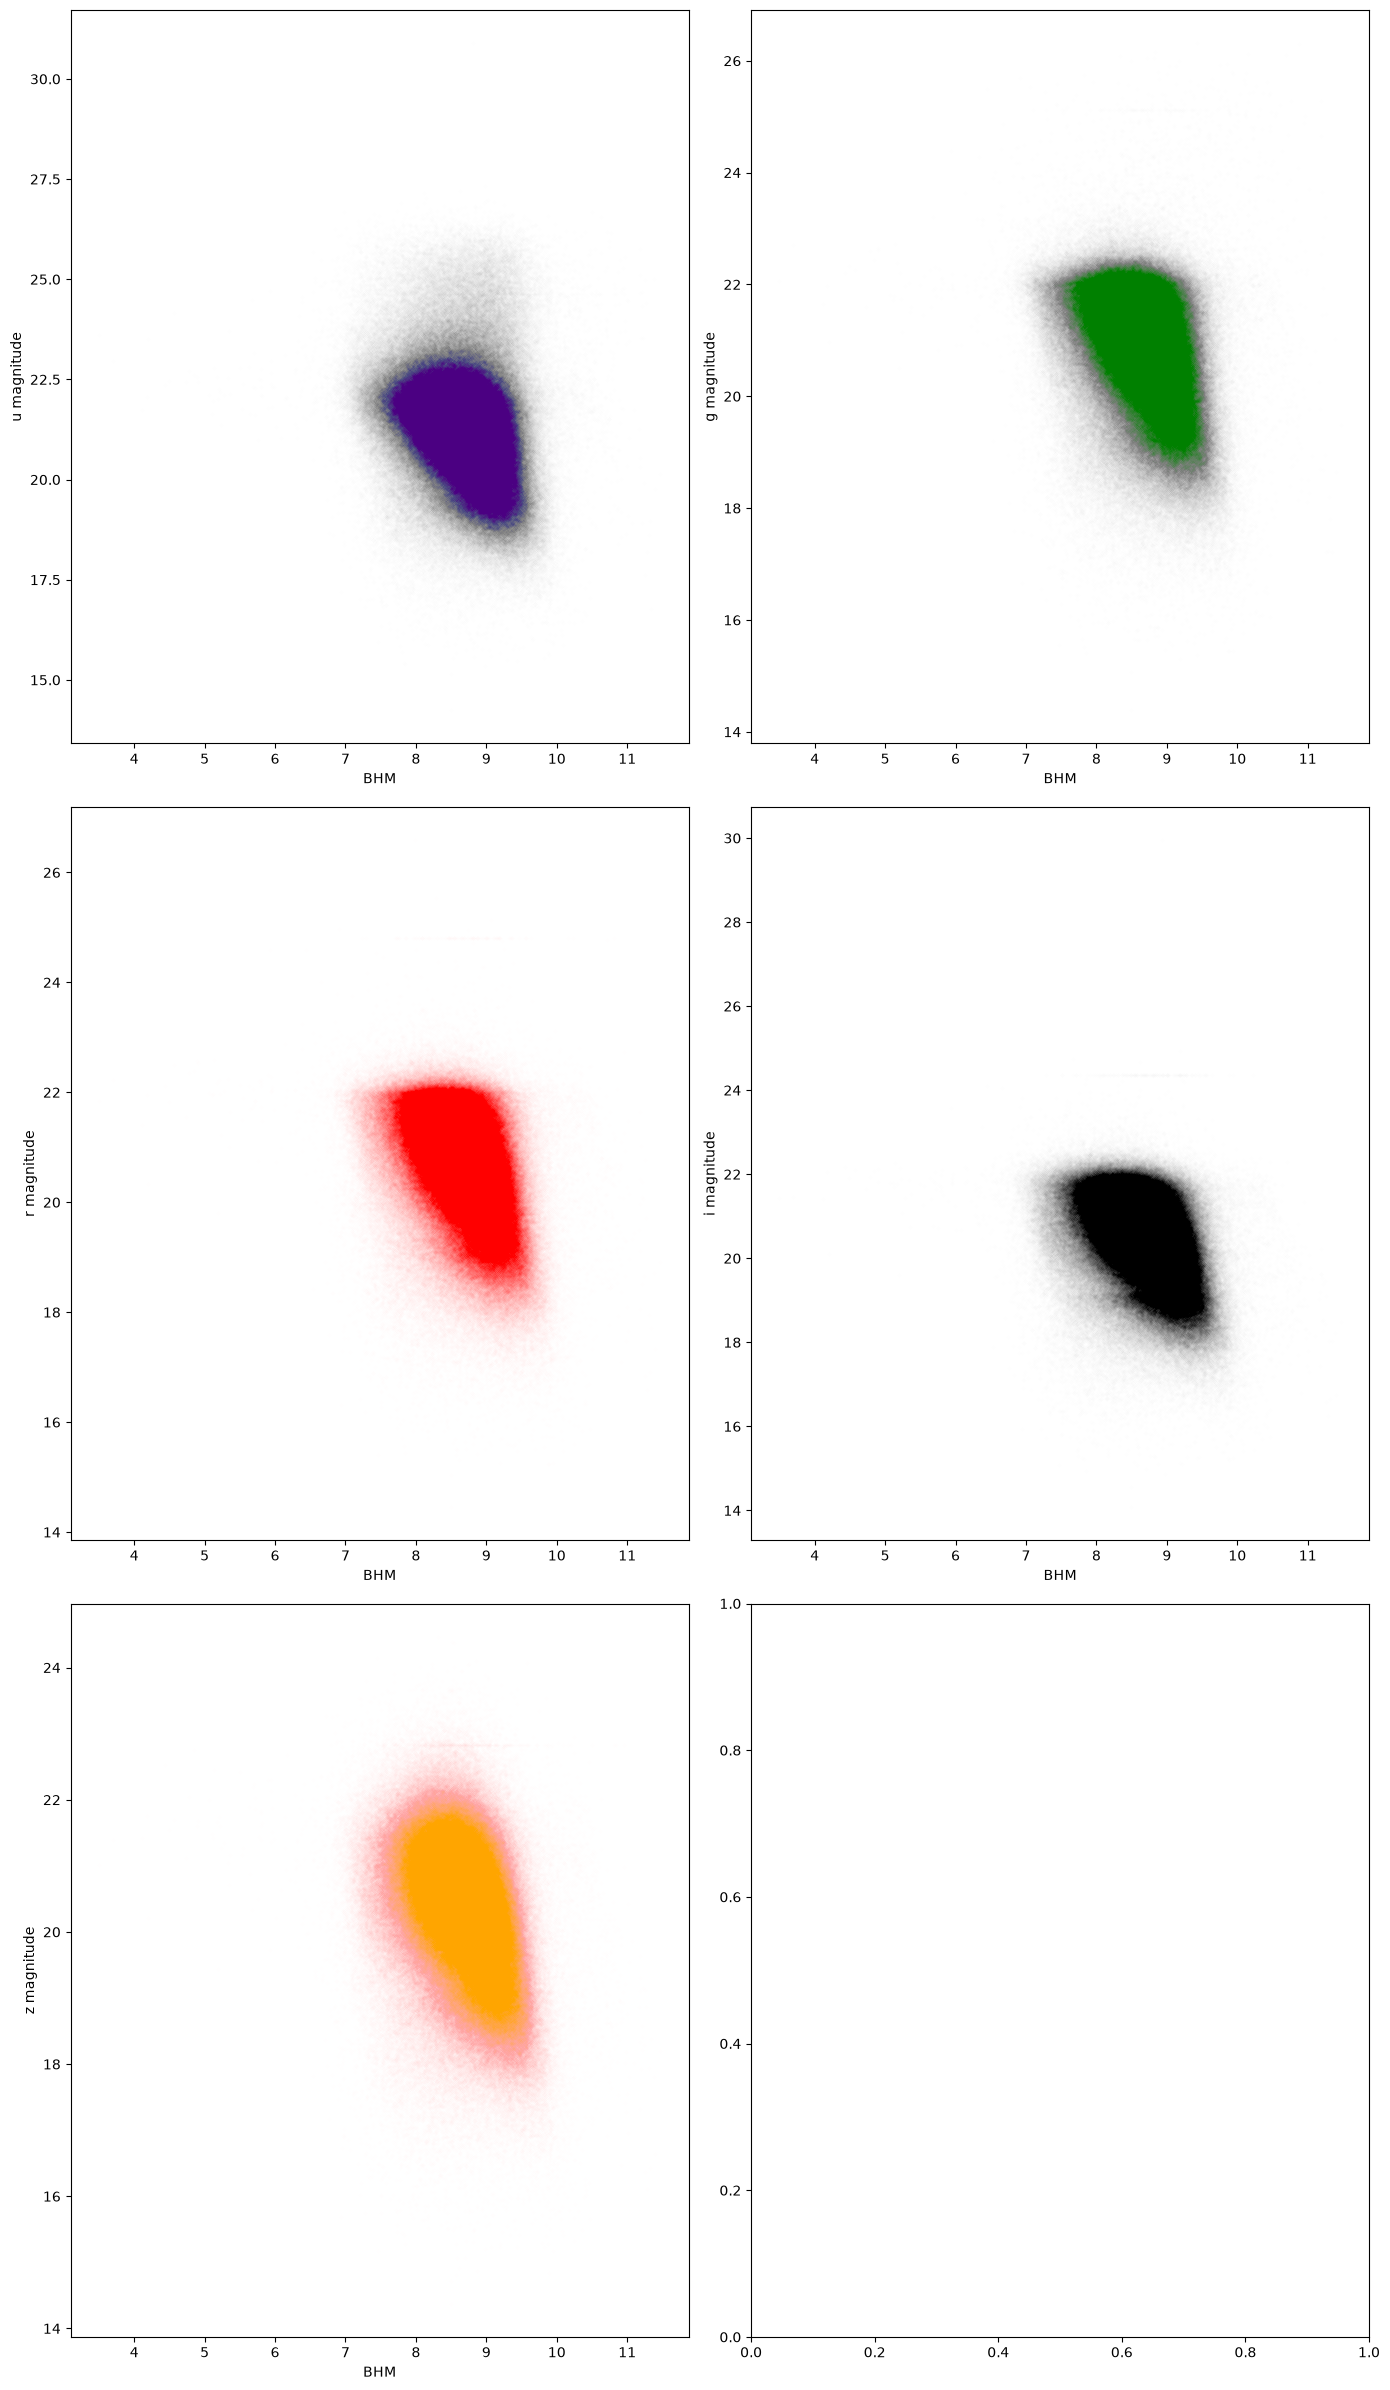

In [23]:



fig, axs = plt.subplots(3, 2, figsize=(14, 24))
axs = axs.ravel()


axs[0].plot(valid_bands_df['LOGMBH'], valid_bands_df['u_mag'], marker=".", color="indigo",ls = '', ms = 6, alpha = 0.005, markeredgewidth=0)
axs[0].set_xlabel("BHM")
axs[0].set_ylabel("u magnitude")

axs[1].plot(valid_bands_df['LOGMBH'], valid_bands_df['g_mag'], marker=".", color="green", ls = '', ms = 6, alpha = 0.005, markeredgewidth=0)
axs[1].set_xlabel("BHM")
axs[1].set_ylabel("g magnitude")

axs[2].plot(valid_bands_df['LOGMBH'], valid_bands_df['r_mag'], marker=".", color="red", ls = '', ms = 6, alpha = 0.005, markeredgewidth=0)
axs[2].set_xlabel("BHM")
axs[2].set_ylabel("r magnitude")

axs[3].plot(valid_bands_df['LOGMBH'], valid_bands_df['i_mag'], marker=".", color="black", ls = '', ms = 6, alpha = 0.005, markeredgewidth=0)
axs[3].set_xlabel("BHM")
axs[3].set_ylabel("i magnitude")

axs[4].plot(valid_bands_df['LOGMBH'], valid_bands_df['z_mag'], marker=".", color="orange", ls = '', ms = 6, alpha = 0.005, markeredgewidth=0)
axs[4].set_xlabel("BHM")
axs[4].set_ylabel("z magnitude")



plt.tight_layout()
plt.show()


In [29]:
print('raw u band = ',data.PSFMAG[500, 0])
print('raw BH = ',data2.LOGMBH[500])

print('masked u band = ', u_mag[500])
print('masked BH = ', BHM[500])
print(len(valid_bands))

raw u band =  21.741287
raw BH =  8.15288169251761
masked u band =  20.445097
masked BH =  9.195640707063642
745275


## Band Comparison

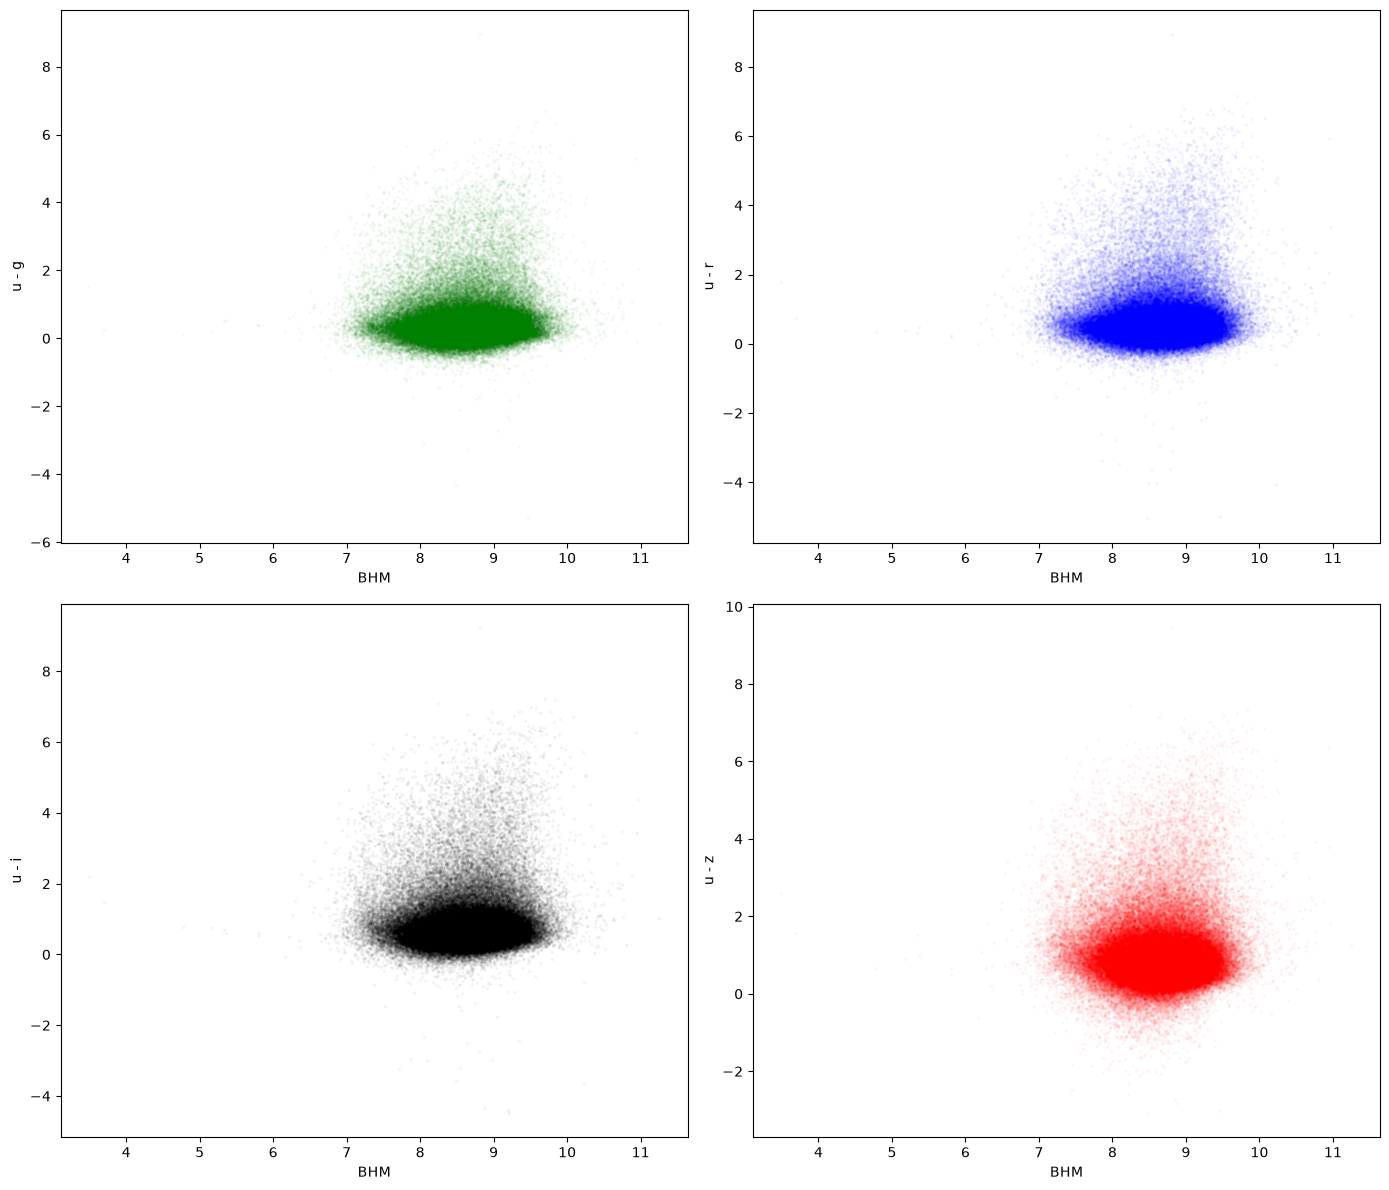

In [31]:
valid_bands_df["u_g"] = valid_bands_df["u_mag"] - valid_bands_df["g_mag"]
valid_bands_df["u_r"] = valid_bands_df["u_mag"] - valid_bands_df["r_mag"]
valid_bands_df["u_i"] = valid_bands_df["u_mag"] - valid_bands_df["i_mag"]
valid_bands_df["u_z"] = valid_bands_df["u_mag"] - valid_bands_df["z_mag"]

fig, axs = plt.subplots(2, 2, figsize=(14, 12))
axs = axs.ravel()

axs[0].plot(valid_bands_df["LOGMBH"][:100000], valid_bands_df["u_g"][:100000], color = 'green', marker=".", ls="", ms=3, alpha=0.03)
axs[0].set_xlabel("BHM")
axs[0].set_ylabel("u - g")

axs[1].plot(valid_bands_df["LOGMBH"][:100000], valid_bands_df["u_r"][:100000], color = 'blue', marker=".", ls="", ms=3, alpha=0.03)
axs[1].set_xlabel("BHM")
axs[1].set_ylabel("u - r")

axs[2].plot(valid_bands_df["LOGMBH"][:100000], valid_bands_df["u_i"][:100000], color = 'black', marker=".", ls="", ms=3, alpha=0.03)
axs[2].set_xlabel("BHM")
axs[2].set_ylabel("u - i")

axs[3].plot(valid_bands_df["LOGMBH"][:100000], valid_bands_df["u_z"][:100000], color = 'red', marker=".", ls="", ms=3, alpha=0.03)
axs[3].set_xlabel("BHM")
axs[3].set_ylabel("u - z")

plt.tight_layout()
plt.show()

## DBSCAN first run (U-band vs BH mass)

In [67]:
X = np.column_stack([data2.LOGMBH[:200000], u_mag[:200000]])

good = ((X[:, 0] != 0) & (X[:, 1] != 0))

X = X[good] 

X = StandardScaler().fit_transform(X)

#labels = DBSCAN(eps=0.3, min_samples=10).fit_predict(X)
db = DBSCAN(eps=0.3, min_samples=10)
labels = db.fit_predict(X)

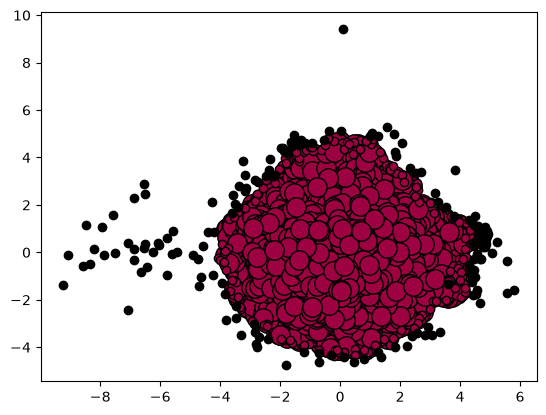

In [68]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col), markeredgecolor="k", markersize=14)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col), markeredgecolor="k", markersize=6)

plt.show()

Clusters: 3
Noise points: 4244


Text(0, 0.5, 'i magnitude')

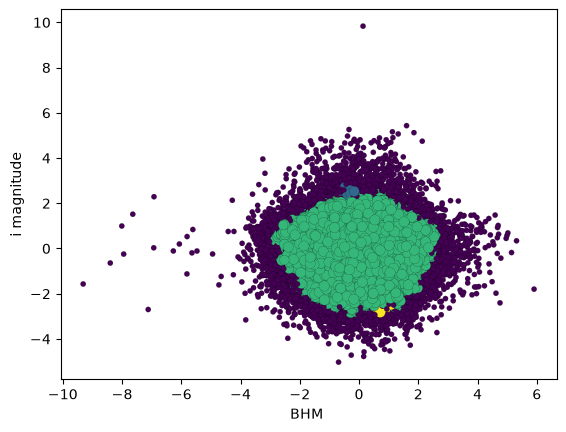

In [74]:
#define the inputs and scale
Y = np.column_stack([data2.LOGMBH[:100000], u_mag[:100000]])
valid = ((Y[:,0] != 0) & (Y[:,1] != 0))
Y = Y[valid]
Y_scaled = StandardScaler(copy = True).fit_transform(Y)

#initiate dbscan
# db = DBSCAN(eps = 0.3,min_samples = 10)
# labels = db.fit_predict(Y_scaled)

#initiate HDBSCAN
db = HDBSCAN(min_cluster_size=50, min_samples=5, copy = True)
labels = db.fit_predict(Y_scaled)

#count clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = labels == -1

print("Clusters:", n_clusters)
print("Noise points:", np.sum(noise))

#define sizes
#DBSCAN
# mask = np.zeros_like(labels, dtype = bool) 
# mask[db.core_sample_indices_] = True 
# sizes = np.where(mask, 40, 15)
#HDBSCAN
sizes = 15 + 40 * db.probabilities_

#plot
# plt.figure(figsize=(4, 2), dpi=200)

plt.scatter(Y_scaled[:,0],Y_scaled[:,1],c = labels, s = sizes, edgecolor = 'black', linewidth = 0.1)
plt.xlabel("BHM ")
plt.ylabel("i magnitude")


## X-ray

0
285603


np.float32(2.4061e-15)

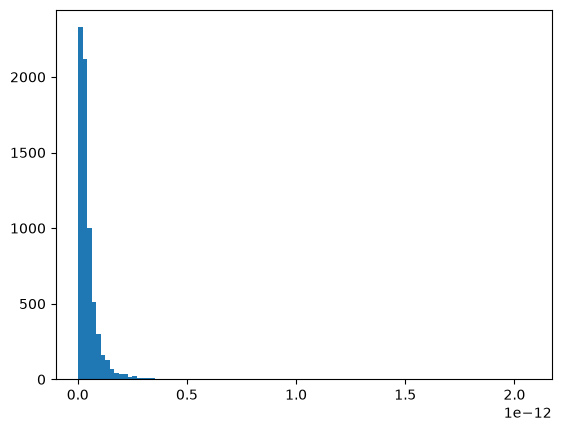

In [15]:
total_xray = data.XMM_TOTAL_FLUX
len(total_xray)
max(total_xray)
min(total_xray)
print(np.sum(total_xray == np.inf))
print(len(total_xray))

xray_mask = (total_xray != -1) & (total_xray != np.inf) & (total_xray != 0)
plt.hist(total_xray[xray_mask], bins = 100)
min(total_xray[xray_mask])

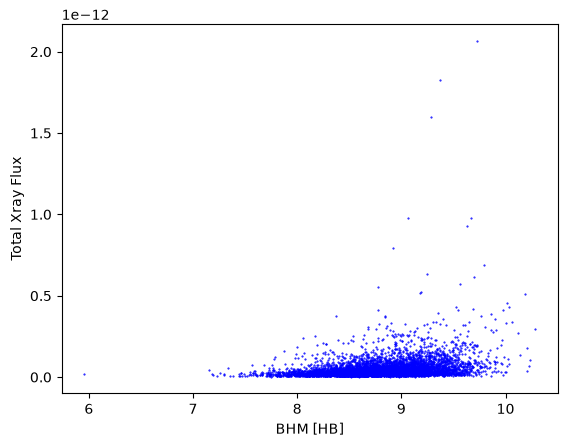

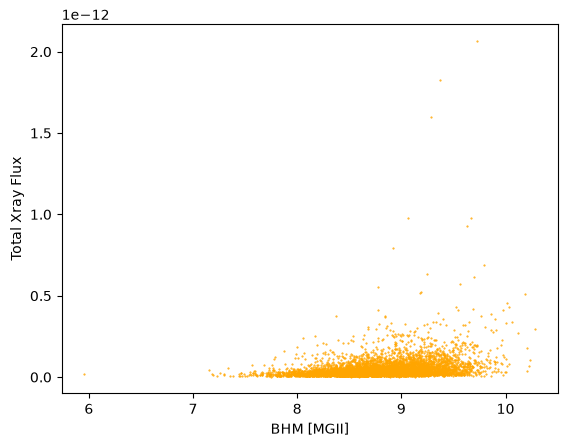

In [16]:
plt.figure()
for i in range(len(data)):
    if data2.LOGMBH[i] != 0 and total_xray[i] != -1 and total_xray[i] != np.inf and total_xray[i] != 0:
        plt.plot(data2.LOGMBH[i], total_xray[i], markersize=1, marker=".", color="blue")
plt.xlabel("BHM [HB]")
plt.ylabel("Total Xray Flux")
plt.show()

plt.figure()
for i in range(len(data)):
    if data2.LOGMBH_MGII[i] != 0 and total_xray[i] != -1 and total_xray[i] != np.inf and total_xray[i] != 0:
        plt.plot(data2.LOGMBH_MGII[i], total_xray[i], markersize=1, marker=".", color="orange")
plt.xlabel("BHM [MGII]")
plt.ylabel("Total Xray Flux")
plt.show()


Clusters: 3
Noise points: 2443


Text(0, 0.5, 'Total Xray Flux')

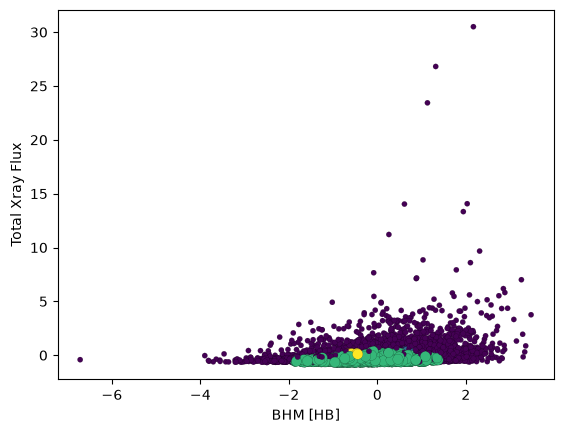

In [17]:
#define the inputs and scale
Y = np.column_stack([data2.LOGMBH[:len(total_xray)], total_xray])
valid = ((Y[:,0] != 0) & (Y[:,1] != -1) & (Y[:,1] != np.inf) & (Y[:,1] != 0))
Y = Y[valid]
Y_scaled = StandardScaler(copy = True).fit_transform(Y)

#initiate dbscan
# db = DBSCAN(eps = 0.3,min_samples = 10)
# labels = db.fit_predict(Y_scaled)

#initiate HDBSCAN
db = HDBSCAN(min_cluster_size=30, min_samples=10, copy = True)
labels = db.fit_predict(Y_scaled)

#count clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = labels == -1

print("Clusters:", n_clusters)
print("Noise points:", np.sum(noise))

#define sizes
#DBSCAN
# mask = np.zeros_like(labels, dtype = bool) 
# mask[db.core_sample_indices_] = True 
# sizes = np.where(mask, 40, 15)
#HDBSCAN
sizes = 15 + 40 * db.probabilities_

#plot
# plt.figure(figsize=(4, 2), dpi=200)

plt.scatter(Y_scaled[:,0],Y_scaled[:,1],c = labels, s = sizes, edgecolor = 'black', linewidth = 0.1)
plt.xlabel("BHM [HB]")
plt.ylabel("Total Xray Flux")


## 3D attempt

In [71]:
#%matplotlib tk

# fig = plt.figure(figsize=(9, 8)) 
# ax = fig.add_subplot(projection='3d')
# ax.set_box_aspect((1, 1, 1))


# for i in range(500000):
#     if data2.LOGMBH[i] != 0 and total_xray[i] != -1 and total_xray[i] != np.inf and total_xray[i] != 0 and data.Z[i] != -999:
#         ax.plot(data2.LOGMBH[i], total_xray[i], data.Z[i], markersize=10, marker=".", color="blue")
# ax.set_xlabel("BHM [HB]", labelpad=15, fontsize = 11)
# ax.set_ylabel("Total X-ray Flux ($10^{-13}$)", labelpad=15, fontsize=11)
# ax.set_zlabel("Redshift", labelpad=15, fontsize = 11)
# ax.set_box_aspect(None, zoom=0.85) 

# plt.tight_layout() 
# plt.show()

# Slow and Laggy ^^^^

x_arr = np.array(data2.LOGMBH)
y_arr = np.array(total_xray)
z_arr = np.array(data.Z)
y_arr_log = np.log10(y_arr)

mask = ((x_arr != 0) & (y_arr != -1) & (y_arr != np.inf) & (y_arr != 0) & (z_arr != -999) & (z_arr < 4) & (z_arr > 0))

plot_df = pd.DataFrame({'BHM': x_arr[mask],'Flux': y_arr_log[mask],'Redshift': z_arr[mask]})

fig = px.scatter_3d(plot_df, x='BHM', y='Flux', z='Redshift',labels={'BHM': 'BHM [HB]', 'Flux': 'Total X-ray Flux','Redshift': 'Redshift'})

fig.update_traces(marker=dict(size=3, color='blue', opacity=0.6))
fig.update_layout(width=900, height=800, template='plotly_white')

fig.show()

/var/folders/0x/tff67vxd02vc2x9f8gxwj3800000gn/T/ipykernel_22926/1806053860.py:24: RuntimeWarning: invalid value encountered in log10
  y_arr_log = np.log10(y_arr)


In [72]:
plot_df['logFlux'] = np.log10(y_arr[mask])
features = plot_df[['BHM', 'logFlux', 'Redshift']]

# features_scaled = StandardScaler().fit_transform(features)

db = HDBSCAN(min_cluster_size=10, min_samples=10, copy=True)

labels = db.fit_predict(features_scaled)

plot_df['cluster_num'] = labels
plot_df['cluster'] = labels.astype(str)

fig = px.scatter_3d(plot_df, x='BHM', y='logFlux', z='Redshift', color='cluster',
labels={'BHM': 'BHM [HB]',
        'logFlux': 'logFlux [log10]',
        'Redshift': 'Redshift',
        'cluster': 'HDBSCAN Cluster'})
fig.update_traces(marker=dict(size=3, opacity=0.6))
fig.update_layout(width=900, height=800, template='plotly_white')

fig.show()


# Outlier Detection method notes

Three methods of detection exist to classify outliers and normal points
## Supervised:
A supervised detection method is one in which a normal classification is defined by an individual, that class is then used to compare other points, if they do not fit the description they are labeled outliers. One can make several classes however this method struggles with inbalance. Most data will have very few outliers in comparison to the normal points. This leaves our classifyer with very little information to learn about outliers. A couple ways to mitigate this are through oversampling or creating artificial outliers.

## Unsupervised:
An unsupervised detection method works with clusters. Data point may make more than one cluster which we can consider to be normal. Any points that are far isolated from a group can then be considered an outlier. This is the kind of method DBSCAN is. The weaknesses of this method is many of these points could be noise instead of actual outliers. Also it is energy intensive due to having to identify all the normal points before you can get to the outliers which is what we care about, having to process seemingly unimportant information is anapealing because its computationally expensive.

## Semi_Supervised
Semi_supervised detection is a combination of the two, again it struggles with low outlier availibility


# 3D Plotting Guide

## 1. Convert arrays to numpy arrays
This makes our data easier to work with and more efficient.<br>
```python
NumPy_array = **np.array**(Regular_array)
```

## 2. Mask
Not every item in our data set contains valuable information, Filter those out by creating a mask which collects only the indexes with useful data. In this case mask is an array containing true and false values, where the true indexes are those which satified the internal conditions.<br>
```python
mask = (NumPy_array != value & etc...)
```

## 3. Create a Pandas Data Frame
The dataframe provides the layout for our data. Here plot_df is a table where the columns are the arrays in which they're listed and the rows are the data.<br>
```python
plot_df = **pd.DataFrame**({'Name': NumPy_array[mask], etc...})
```

## 4. Plotting
We create our figure using the plotting function **px.scatter_3d**, Within the function we write in our data frame (plot_df), we assign the axis to each column by name, and we add labels to each axis.<br>
```python
fig = px.scatter_3d(plot_df, x='C_1', y='C_2', z='C_3', labels={'C_1': 'Axis_label', etc...})
```
## 5. Customize Plot
To alter the visuals on our figure use functions **update_traces** and **update_layout**
```python
fig.update_traces(marker=dict(size=3, color='blue', opacity=0.6))
fig.update_layout(width=900, height=800, template='plotly_white')
```
## 6. Display the Figure
```python
fig.show()
```

## 7. Define Features for HBDSCAN
HBDSCAN requires our parameters to be defined under features.<br>
```python
features = plot_df[['C_1', 'C_2', 'C_3']]
```
<br>

**Note:** Keep an eye on the orders of magnitude, if on axis is much great apply log scaling to that data set with **np.log10**.<br>
```python
plot_df['logFlux'] = np.log10(plot_df['Flux'])
features = plot_df[['BHM', 'logFlux', 'Redshift']]
```

## 8. Scaling
Because HBDSCAN works with distance we need to scale our features, this makes sure that the difference in scale between the measurments doesn't create bias.<br>
```python
features_scaled = StandardScaler().fit_transform(features)
```

## 9. Create HDBSCAN Model
Initiate HDBSCAN, assign model values and create your labels.<br>
```python
db = HDBSCAN(min_cluster_size=20, min_samples=10, copy=True)

labels = db.fit_predict(features_scaled)
```

## 10. HDBSCAN to DataFrame
We must add our labels result from HBDSCAN to our dataframe to use it in plotly.<br>
```python
plot_df['cluster_num'] = labels
plot_df['cluster'] = labels.astype(str)
```

## 11. Plotly with HBDSCAN
To add HBDSCAN to our figure, add these parameters into the previous **px.scatter_3d** function:<br>
```python
color='cluster', size='strength',
labels={'C_1': 'Axis label 1',
        'C_2': 'Axis label 2',
        'C_3': 'Axis label 3',
        'cluster': 'HDBSCAN Cluster',
        'strength': 'Membership Strength'}
```

for each cluster stack and "average" their spectra to view pattern?
